In [4]:
using LinearAlgebra
using CSV, DataFrames, Statistics, Random, Distributions

include("calculate_phase_split.jl")

"""
Run uncertainty propagation with optional Morris sensitivity weighting (micro-UQ)
"""

function uncertainty_analysis(
    tau_file::String,
    feed_compositions::Vector,
    n_samples::Int=20,
    output_dir::String="UncertaintyOutcomes";
    morris_mu_star::Dict = Dict((1,3)=>0.45,(3,1)=>0.20)
)
    println("="^70)
    println("Fast Uncertainty Propagation (Morris-guided micro-UQ)")
    println("="^70)
    println("Tau file: $tau_file")
    println("Feeds: $(length(feed_compositions)), Samples per feed: $n_samples")
    println("="^70)

    if !isdir(output_dir)
        mkdir(output_dir)
        println("Created directory: $output_dir")
    end

    # === Load τ ===
    base_tau = read_tau_matrix(tau_file)

    Random.seed!(1234)

    # Select top 2 most influential τ entries
    sorted = sort(collect(morris_mu_star), by=x->-x[2])
    top_entries = first.(sorted[1:min(2,length(sorted))])
    println("Perturbing τ entries: ", top_entries)
    println()

    all_results = []

    for (feed_idx, z_feed) in enumerate(feed_compositions)
        println("\n", "="^70)
        println("Feed Composition $feed_idx: ", z_feed)
        println("="^70)

        feed_results = []
        for i in 1:n_samples
            print("  Sample $i/$n_samples... ")

            τp = copy(base_tau)
            # perturb only influential τ entries
            for (ii, jj) in top_entries
                τp[ii,jj] *= (1 + 0.02 * (2rand() - 1)) # ±2% random
            end

            # Solve
            try
                x1, x2 = solve_lle(z_feed, τp)

                if any(isnan, x1) || any(isnan, x2)
                    println("NaN")
                    status = "failed"
                    sep = NaN
                else
                    sep = norm(x1 - x2)
                    status = if sep < 0.8 || sep > 1.5 "outlier" else "valid" end
                    println(status == "valid" ? "✓" : "⚠ $(status)")
                end

                push!(feed_results, Dict(
                    :feed_idx => feed_idx,
                    :feed_water => z_feed[1],
                    :feed_furfural => z_feed[2],
                    :feed_ea => z_feed[3],
                    :sample => i,
                    :phase1_water => x1[1],
                    :phase1_furfural => x1[2],
                    :phase1_ea => x1[3],
                    :phase2_water => x2[1],
                    :phase2_furfural => x2[2],
                    :phase2_ea => x2[3],
                    :separation => sep,
                    :status => status
                ))
            catch e
                println("ERROR: $e")
                push!(feed_results, Dict(
                    :feed_idx => feed_idx,
                    :feed_water => z_feed[1],
                    :feed_furfural => z_feed[2],
                    :feed_ea => z_feed[3],
                    :sample => i,
                    :phase1_water => NaN,
                    :phase1_furfural => NaN,
                    :phase1_ea => NaN,
                    :phase2_water => NaN,
                    :phase2_furfural => NaN,
                    :phase2_ea => NaN,
                    :separation => NaN,
                    :status => "error"
                ))
            end
        end

        # === Feed-level stats ===
        feed_df = DataFrame(feed_results)
        valid_df = feed_df[feed_df.status .== "valid", :]
        println("  Valid: $(nrow(valid_df)) / $n_samples")

        if nrow(valid_df) > 0
            println("  Δphase separation = $(round(std(valid_df.separation),digits=3))")
            println("  EA extract = $(round(mean(valid_df.phase2_ea)*100,digits=1)) ± $(round(std(valid_df.phase2_ea)*100,digits=1)) %")

            # ADDED: quick log K summary per feed
            logK_vals = log.(valid_df.phase2_furfural ./ valid_df.phase1_furfural)
            println("  log K = $(round(mean(logK_vals),digits=3)) ± $(round(std(logK_vals),digits=3))")
        end

        # Save feed results
        feed_filename = joinpath(output_dir, "feed_$(feed_idx).csv")
        CSV.write(feed_filename, feed_df)
        append!(all_results, feed_results)
    end

    # === Combined stats ===
    println("\n", "="^70)
    println("OVERALL SUMMARY")
    println("="^70)

    all_df = DataFrame(all_results)
    valid_all = all_df[all_df.status .== "valid", :]

    if nrow(valid_all) > 0
        # ADDED: compute log K column
        valid_all.logK = log.(valid_all.phase2_furfural ./ valid_all.phase1_furfural)

        # UPDATED: expanded summary
        summary = combine(groupby(valid_all, :feed_idx),
            :separation => mean => :sep_mean,
            :separation => std  => :sep_std,
            :phase1_water => mean => :water_mean,
            :phase1_water => std  => :water_std,           # ADDED
            :phase2_ea => mean => :ea_mean,
            :phase2_ea => std  => :ea_std,
            :phase1_furfural => mean => :furf_aq_mean,    # ADDED
            :phase1_furfural => std  => :furf_aq_std,     # ADDED
            :phase2_furfural => mean => :furf_org_mean,   # ADDED
            :phase2_furfural => std  => :furf_org_std,    # ADDED
            :logK => mean => :logK_mean,                  # ADDED
            :logK => std  => :logK_std                    # ADDED
        )

        CSV.write(joinpath(output_dir, "summary_microUQ_all_stats.csv"), summary)
        println("Saved summary_microUQ_all_stats.csv")
    end

    return all_df, valid_all
end


feeds = [
    [0.205, 0.110, 0.685],
    [0.302, 0.120, 0.578],
    [0.410, 0.120, 0.470],
    [0.513, 0.103, 0.385],
    [0.610, 0.103, 0.287]
]

all_results, valid_results = uncertainty_analysis(
    "fitted_tau_matrix_2_5.csv",
    feeds,
    20
)

Fast Uncertainty Propagation (Morris-guided micro-UQ)
Tau file: fitted_tau_matrix_2_5.csv
Feeds: 5, Samples per feed: 20
Loaded tau matrix from fitted_tau_matrix_2_5.csv:


3×3 Matrix{Float64}:
 0.0       3.00421    4.02985
 2.31201   0.0       -1.87704
 2.84445  -0.321599   0.0

Perturbing τ entries: [(1, 3), (3, 1)]


Feed Composition 1: [0.205, 0.11, 0.685]
  Sample 1/20... 

┌ Warning: Initial position cannot be on the boundary of the box. Moving elements to the interior.
│ Element indices affected: [5]
└ @ Optim ~/.julia/packages/Optim/7krni/src/multivariate/solvers/constrained/fminbox.jl:441


⚠ outlier
  Sample 2/20... ⚠ outlier


...

┌ Warning: Initial position cannot be on the boundary of the box. Moving elements to the interior.
│ Element indices affected: [5]
└ @ Optim ~/.julia/packages/Optim/7krni/src/multivariate/solvers/constrained/fminbox.jl:441


  Sample 20/20... ✓


┌ Warning: Initial position cannot be on the boundary of the box. Moving elements to the interior.
│ Element indices affected: [5]
└ @ Optim ~/.julia/packages/Optim/7krni/src/multivariate/solvers/constrained/fminbox.jl:441


  Valid: 20 / 20
  Δphase separation = 0.008
  EA extract = 61.0 ± 0.4 %
  log K = 2.429 ± 0.017

OVERALL SUMMARY
Saved summary_microUQ_all_stats.csv


(100×13 DataFrame
 Row │ phase1_furfural  status   feed_water  separation  feed_idx  feed_furfur ⋯
     │ Float64          String   Float64     Float64     Int64     Float64     ⋯
─────┼──────────────────────────────────────────────────────────────────────────
   1 │      0.0438078   outlier       0.205    0.504334         1          0.1 ⋯
   2 │      0.0439011   outlier       0.205    0.505714         1          0.1
   3 │      0.0437485   outlier       0.205    0.503805         1          0.1
   4 │      0.0444163   outlier       0.205    0.502634         1          0.1
   5 │      0.0440409   outlier       0.205    0.504206         1          0.1 ⋯
   6 │      0.044095    outlier       0.205    0.503829         1          0.1
   7 │      0.0433799   outlier       0.205    0.504659         1          0.1
   8 │      0.0439644   outlier       0.205    0.504246         1          0.1
   9 │      0.0443416   outlier       0.205    0.502249         1          0.1 ⋯
  10 │      0.00893035

GKS: glyph missing from current font: 8321
GKS: glyph missing from current font: 8320
GKS: glyph missing from current font: 8321
GKS: glyph missing from current font: 8320


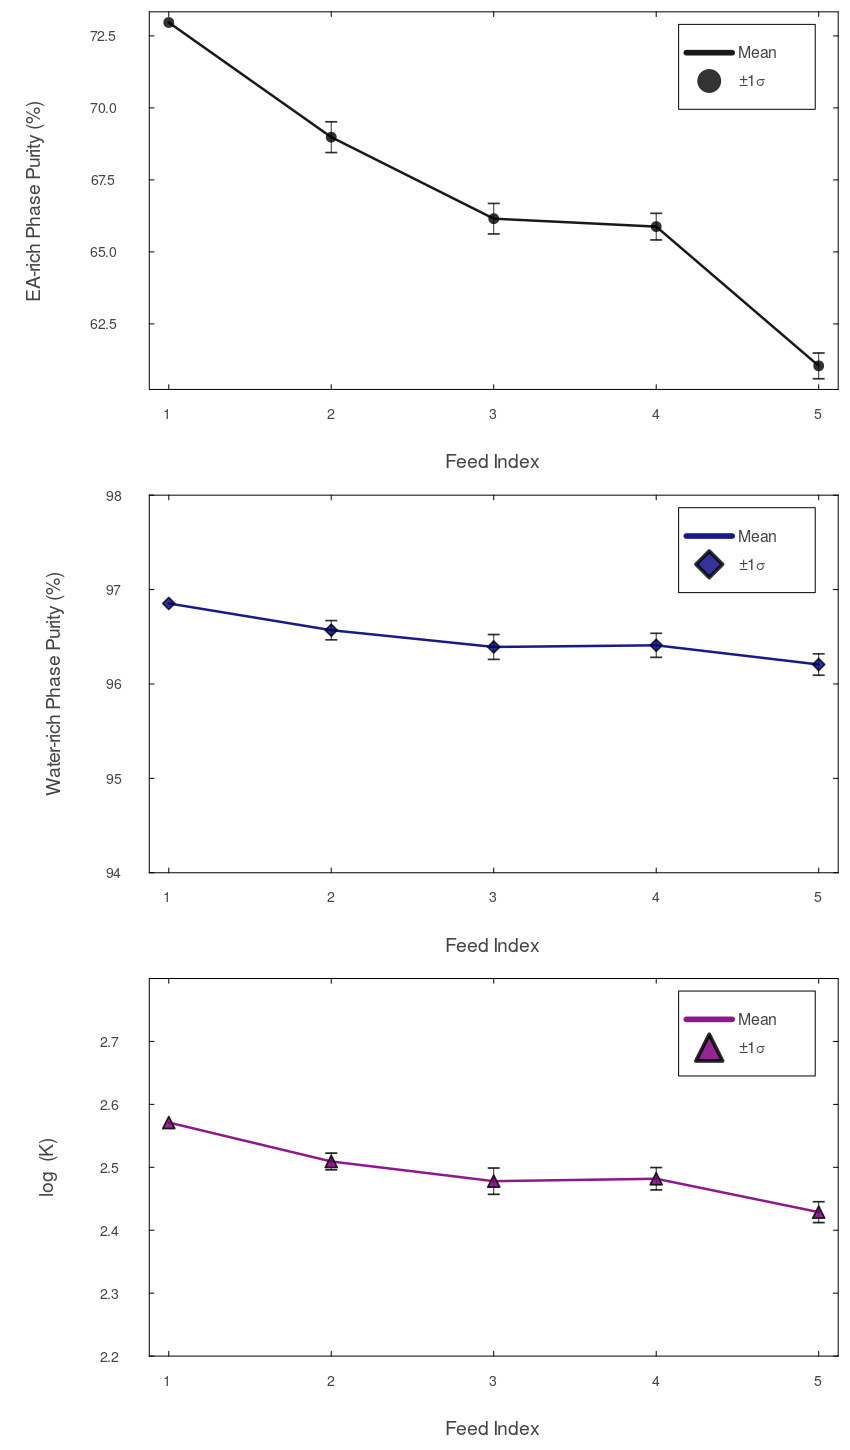

Uncertainty plots saved to 'UncertaintyOutcomes/uncertainty_summary_plots_all_stats.png'


GKS: glyph missing from current font: 8321
GKS: glyph missing from current font: 8320
GKS: glyph missing from current font: 8321
GKS: glyph missing from current font: 8320


In [76]:
using CSV, DataFrames, Plots, Statistics

summary_df = CSV.read(joinpath("UncertaintyOutcomes", "summary_microUQ_all_stats.csv"), DataFrame)

sort!(summary_df, :feed_idx)

# Set back end 
gr()

#  General plot style
default(
    fontfamily = "Helvetica",
    linewidth = 2.5,
    markersize = 6,
    legend = :topright,
    framestyle = :box,
    grid = false,
    alpha = 0.9, 
    guidefont = 22,    
    tickfont = 16,   
    legendfont = 18,
)

# EA phase purity and std
p1 = plot(
    summary_df.feed_idx, summary_df.ea_mean .* 100,
    seriestype = :line, color = :black, label = "Mean",
    xlabel = "Feed Index",
    ylabel = "EA-rich Phase Purity (%)",
    title = ""
)
scatter!(
    summary_df.feed_idx, summary_df.ea_mean .* 100,
    yerror = summary_df.ea_std .* 100,
    color = :black, marker = :circle, alpha = 0.8,
    label = "±1σ"
)

# Water phase purity and std
p2 = plot(
    summary_df.feed_idx, summary_df.water_mean .* 100,
    seriestype = :line, color = :navy, label = "Mean",
    xlabel = "Feed Index",
    ylabel = "Water-rich Phase Purity (%)",
    ylims = (94, 98),
    title = ""
)
scatter!(
    summary_df.feed_idx, summary_df.water_mean .* 100,
    yerror = summary_df.water_std .* 100,
    color = :navy, marker = :diamond, alpha = 0.8,
    label = "±1σ"
)

#=
# Phase separation magnitude and std
p3 = plot(
    summary_df.feed_idx, summary_df.sep_mean,
    seriestype = :line, color = :darkgreen, label = "Mean",
    xlabel = "Feed Index",
    ylabel = "Phase Separation (‖x₁ − x₂‖)",
    title = "Phase Split Magnitude Across Feeds"
)
scatter!(
    summary_df.feed_idx, summary_df.sep_mean,
    yerror = summary_df.sep_std,
    color = :darkgreen, marker = :utriangle, alpha = 0.8,
    label = "±1σ"
)

# Furf in both phases and std
aq_vals = summary_df.furf_aq_mean .* 100
org_vals = summary_df.furf_org_mean .* 100
ymin = min(minimum(aq_vals), minimum(org_vals)) - 0.1
ymax = max(maximum(aq_vals), maximum(org_vals)) + 0.1

p4 = plot(
    summary_df.feed_idx, aq_vals,
    seriestype = :line,
    color = :dodgerblue,
    linewidth = 2.8,
    label = "Aqueous (mean)",
    xlabel = "Feed Index",
    ylabel = "Furfural (%)",
    title = "Furfural Distribution (Aqueous vs Organic)",
    ylims = (ymin, ymax)
)
plot!(
    summary_df.feed_idx, aq_vals,
    yerror = summary_df.furf_aq_std .* 100,
    seriestype = :scatter,
    color = :dodgerblue,
    marker = :diamond,
    markersize = 4,
    alpha = 0.6,
    label = "Aqueous (±1σ)"
)
plot!(
    summary_df.feed_idx, org_vals,
    seriestype = :line,
    color = :orange,
    linewidth = 2.8,
    label = "Organic (mean)"
)
plot!(
    summary_df.feed_idx, org_vals,
    yerror = summary_df.furf_org_std .* 100,
    seriestype = :scatter,
    color = :orange,
    marker = :circle,
    markersize = 4,
    alpha = 0.6,
    label = "Organic (±1σ)"
)
=#

# log K (partition coeff) and std 
p5 = plot(
    summary_df.feed_idx, summary_df.logK_mean,
    seriestype = :line, color = :purple, label = "Mean",
    xlabel = "Feed Index",
    ylabel = "log₁₀(K)",
    ylims = (2.2, 2.8),
    title = ""
)
scatter!(
    summary_df.feed_idx, summary_df.logK_mean,
    yerror = summary_df.logK_std,
    color = :purple, marker = :utriangle, alpha = 0.85,
    label = "±1σ"
)

plt = plot(
    p1, p2, p5,
    layout = (3, 1),
    size = (850, 1450),
    left_margin = 16Plots.mm
)

savefig(plt, joinpath("UncertaintyOutcomes", "uncertainty_summary_plots_all_stats.png"))
display(plt)

println("Uncertainty plots saved to 'UncertaintyOutcomes/uncertainty_summary_plots_all_stats.png'")




In [78]:
using Plots, Statistics

# Assume 'valid_results' or 'all_results' already exist in memory
df = deepcopy(valid_results)  # or all_results if you prefer including outliers

# Quick check
println("Plotting $(nrow(df)) samples from $(length(unique(df.feed_idx))) feeds")

# === Plot setup ===
default(
    fontfamily = "Helvetica",
    linewidth = 2,
    markersize = 6,
    grid = false,
    legend = :topright,
    framestyle = :box
)

# === Scatter plot of all sample separations ===
p = scatter(
    df.feed_idx,
    df.separation,
    group = df.feed_idx,
    xlabel = "Feed Index",
    ylabel = "Phase Separation (‖x₁ − x₂‖)",
    title = "Per-sample Phase Separation Across Feeds",
    markerstrokewidth = 0.5,
    label = "Feed"
)

# Add mean line per feed
means = combine(groupby(df, :feed_idx), :separation => mean => :sep_mean)
plot!(means.feed_idx, means.sep_mean, seriestype = :line, lw = 2, color = :black, label = "Mean")

savefig(p, "UncertaintyOutcomes/phase_separation_scatter_temp_all_stats.png")
display(p)

println("✅ Saved temporary scatter plot to 'UncertaintyOutcomes/phase_separation_scatter_temp.png'")


LoadError: UndefVarError: `valid_results` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [77]:
using Plots, Statistics, DataFrames

df = deepcopy(valid_results)
println("Plotting $(nrow(df)) samples from $(length(unique(df.feed_idx))) feeds")

# === Plot setup ===
default(
    fontfamily = "Helvetica",
    linewidth = 2,
    markersize = 6,
    grid = false,
    legend = :topright,
    framestyle = :box
)

# === Base: all samples (semi-transparent gray) ===
p = scatter(
    df.feed_idx,
    df.separation,
    color = RGBA(0.4, 0.4, 0.4, 0.5),   # 50% transparent fill
    markerstrokecolor = RGBA(0.2, 0.2, 0.2, 0.5),  # 50% transparent border
    marker = :circle,
    label = "All samples"
)

# === Compute statistics by feed ===
stats = combine(groupby(df, :feed_idx)) do sub
    (; feed_idx = first(sub.feed_idx),
       mean = mean(sub.separation),
       std = std(sub.separation),
       q25 = quantile(sub.separation, 0.25),
       q75 = quantile(sub.separation, 0.75))
end

# === Overlay: feed means ===
plot!(
    stats.feed_idx,
    stats.mean,
    seriestype = :scatter,
    color = :black,
    marker = :circle,
    label = "Feed mean"
)

# === Add box-plot style lines (quartile & whiskers) ===
for i in 1:nrow(stats)
    # "Box" between Q1 and Q3
    plot!([stats.feed_idx[i], stats.feed_idx[i]],
          [stats.q25[i], stats.q75[i]],
          color = :black,
          lw = 3,
          label = i == 1 ? "Q1–Q3 range" : "")

    # Whiskers (mean ± std)
    plot!([stats.feed_idx[i], stats.feed_idx[i]],
          [stats.mean[i] - stats.std[i], stats.mean[i] + stats.std[i]],
          color = :black,
          lw = 1.5,
          linestyle = :dash,
          label = i == 1 ? "±1σ" : "")
end

# === Mean connecting line ===
plot!(
    stats.feed_idx,
    stats.mean,
    seriestype = :line,
    color = :black,
    lw = 2,
    label = ""
)

xlabel!("Feed Index")
ylabel!("Phase Separation (‖x₁ − x₂‖)")
title!("Phase Separations with Feed Statistics")

savefig(p, "UncertaintyOutcomes/phase_separation_overlay_final.png")
display(p)

println("✅ Saved overlay plot to 'UncertaintyOutcomes/phase_separation_overlay_final.png'")




LoadError: UndefVarError: `valid_results` not defined in `Main`
Suggestion: check for spelling errors or missing imports.